=== ANALISIS OUTLIER WAKTU RESPON ===
Total URL: 100
Rata-rata waktu respon: 6.29 detik
Median waktu respon: 7.49 detik
Std deviation: 7.22 detik

=== OUTLIER (> 10 detik) ===
Jumlah outlier: 5 dari 100 URL (5.0%)

=== STATISTIK PER DOMAIN ===
                                     Total_URL  Mean_Response  \
Domain                                                          
haluansumatera.com                           1          35.52   
beritapress.id                               7           8.74   
saungnews.co                                 6           8.26   
intinews.co                                 14           8.21   
kabarmegapolitan.pikiran-rakyat.com          2           7.72   
sumsel.akurat.co                             1           7.66   
sonorapalembang.com                          3           7.61   
wideazone.com                                2           7.61   
wawberita.com                                2           7.59   
indoparlemenews.co                       

c:\Users\ACER\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\ACER\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


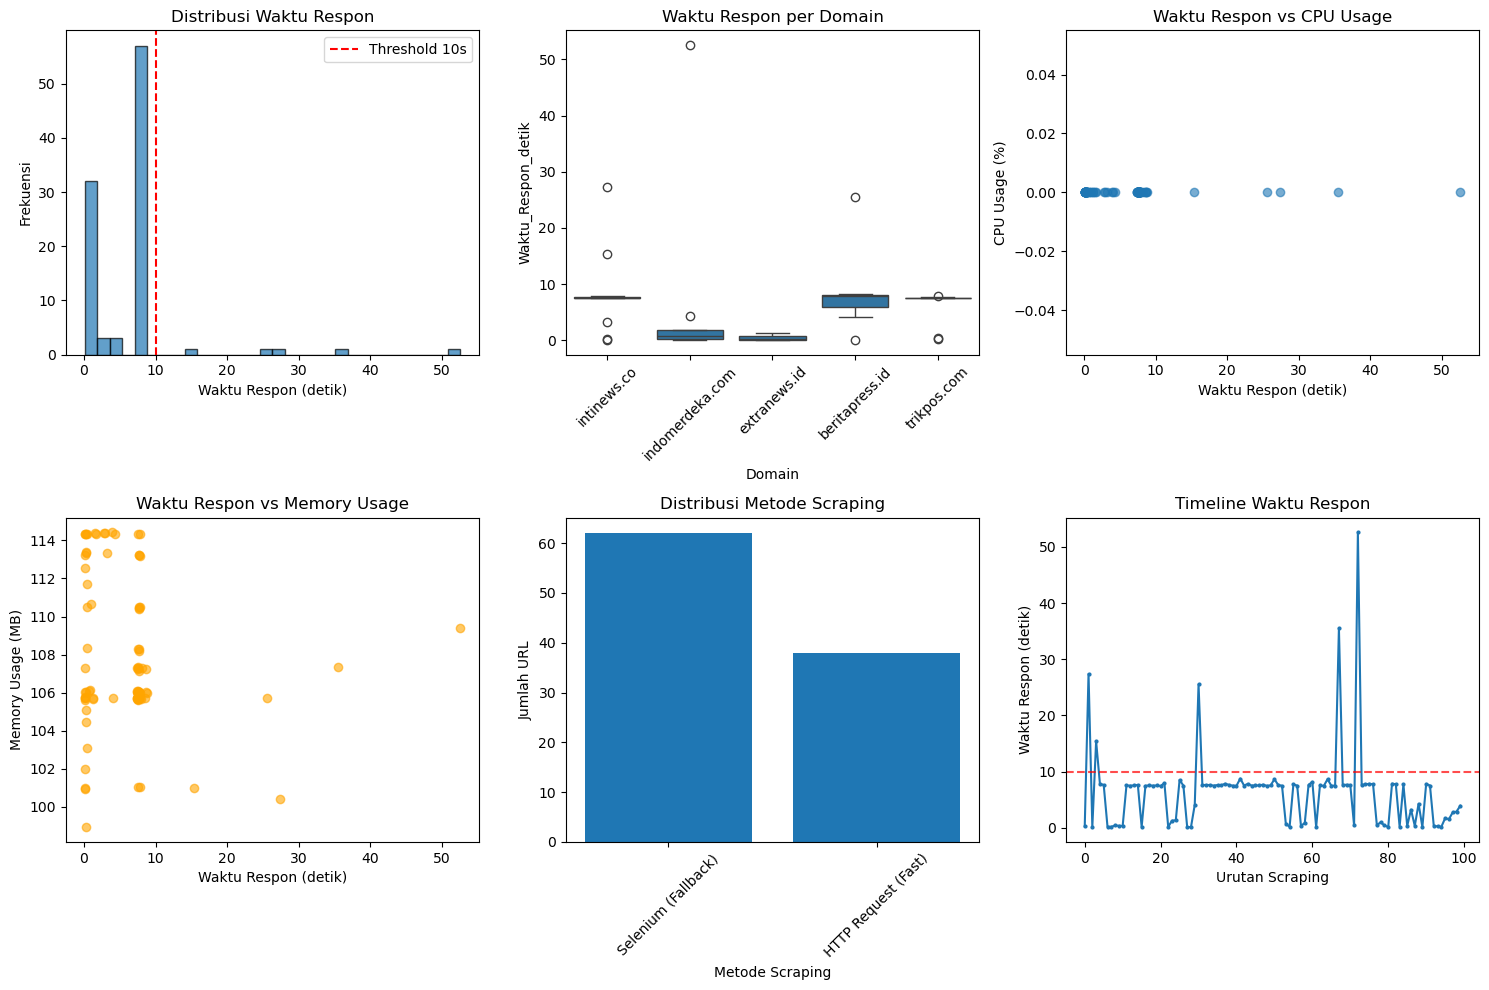


=== REKOMENDASI OPTIMASI ===
1. 62.0% URL menggunakan Selenium fallback
   → Pertimbangkan optimasi headers/user-agent untuk mengurangi 403/415 errors
2. Domain bermasalah: beritapress.id, haluansumatera.com, indomerdeka.com, indoparlemenews.co, intinews.co, kabarmegapolitan.pikiran-rakyat.com, lintaswaranews.co, saungnews.co, sonorapalembang.com, sumsel.akurat.co, sumselnews.co.id, trikpos.com, wawberita.com, wideazone.com
   → Implementasi rate limiting atau caching untuk domain ini
4. 5 URL membutuhkan waktu > 10 detik
   → Implementasi timeout yang lebih agresif atau retry mechanism

=== FILE OUTPUT ===
- outliers_analysis.csv: Detail semua outlier
- domain_performance_stats.csv: Statistik per domain
- analisis_outlier_scraping.png: Visualisasi lengkap


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from urllib.parse import urlparse

# Baca data hasil scraping
df = pd.read_csv('hasil_scraping_sumberdaya.csv')

# 1. IDENTIFIKASI OUTLIER BERDASARKAN WAKTU RESPON
print("=== ANALISIS OUTLIER WAKTU RESPON ===")
print(f"Total URL: {len(df)}")
print(f"Rata-rata waktu respon: {df['Waktu_Respon_detik'].mean():.2f} detik")
print(f"Median waktu respon: {df['Waktu_Respon_detik'].median():.2f} detik")
print(f"Std deviation: {df['Waktu_Respon_detik'].std():.2f} detik")

# Tentukan threshold outlier (misalnya di atas 10 detik)
threshold_outlier = 10
outliers = df[df['Waktu_Respon_detik'] > threshold_outlier]

print(f"\n=== OUTLIER (> {threshold_outlier} detik) ===")
print(f"Jumlah outlier: {len(outliers)} dari {len(df)} URL ({len(outliers)/len(df)*100:.1f}%)")

# 2. ANALISIS BERDASARKAN DOMAIN
def extract_domain(url):
    return urlparse(url).netloc

df['Domain'] = df['URL'].apply(extract_domain)

# Analisis per domain
domain_stats = df.groupby('Domain').agg({
    'Waktu_Respon_detik': ['count', 'mean', 'median', 'max', 'min'],
    'Status': lambda x: (x == 'Berhasil').sum()
}).round(2)

domain_stats.columns = ['Total_URL', 'Mean_Response', 'Median_Response', 'Max_Response', 'Min_Response', 'Success_Count']
domain_stats['Success_Rate'] = (domain_stats['Success_Count'] / domain_stats['Total_URL'] * 100).round(1)

print(f"\n=== STATISTIK PER DOMAIN ===")
print(domain_stats.sort_values('Mean_Response', ascending=False))

# 3. IDENTIFIKASI METODE SCRAPING YANG DIGUNAKAN
# Berdasarkan output log, kita bisa mengidentifikasi metode yang digunakan
def identify_scraping_method(row):
    if row['Waktu_Respon_detik'] > 5:  # Biasanya Selenium lebih lama
        return 'Selenium (Fallback)'
    else:
        return 'HTTP Request (Fast)'

df['Metode_Scraping'] = df.apply(identify_scraping_method, axis=1)

method_stats = df.groupby('Metode_Scraping').agg({
    'Waktu_Respon_detik': ['count', 'mean', 'median', 'max'],
    'CPU_Usage_persen': 'mean',
    'Memory_Usage_MB': 'mean'
}).round(2)

print(f"\n=== ANALISIS BERDASARKAN METODE SCRAPING ===")
print(method_stats)

# 4. DETAIL OUTLIER TERBESAR
print(f"\n=== TOP 10 OUTLIER TERLAMA ===")
top_outliers = df.nlargest(10, 'Waktu_Respon_detik')[['URL', 'Waktu_Respon_detik', 'Domain', 'Metode_Scraping', 'CPU_Usage_persen', 'Memory_Usage_MB']]
for idx, row in top_outliers.iterrows():
    print(f"\n{idx+1}. Domain: {row['Domain']}")
    print(f"   Waktu: {row['Waktu_Respon_detik']:.2f} detik")
    print(f"   Metode: {row['Metode_Scraping']}")
    print(f"   CPU: {row['CPU_Usage_persen']:.1f}% | Memory: {row['Memory_Usage_MB']:.1f} MB")
    print(f"   URL: {row['URL'][:80]}...")

# 5. KORELASI ANTARA RESOURCE USAGE DAN WAKTU RESPON
correlation_time_cpu = df['Waktu_Respon_detik'].corr(df['CPU_Usage_persen'])
correlation_time_memory = df['Waktu_Respon_detik'].corr(df['Memory_Usage_MB'])

print(f"\n=== KORELASI RESOURCE USAGE ===")
print(f"Korelasi Waktu vs CPU Usage: {correlation_time_cpu:.3f}")
print(f"Korelasi Waktu vs Memory Usage: {correlation_time_memory:.3f}")

# 6. VISUALISASI
plt.figure(figsize=(15, 10))

# Plot 1: Distribusi waktu respon
plt.subplot(2, 3, 1)
plt.hist(df['Waktu_Respon_detik'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(threshold_outlier, color='red', linestyle='--', label=f'Threshold {threshold_outlier}s')
plt.xlabel('Waktu Respon (detik)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Waktu Respon')
plt.legend()

# Plot 2: Boxplot per domain (top 5 domain dengan most URLs)
plt.subplot(2, 3, 2)
top_domains = df['Domain'].value_counts().head(5).index
df_top_domains = df[df['Domain'].isin(top_domains)]
sns.boxplot(data=df_top_domains, x='Domain', y='Waktu_Respon_detik')
plt.xticks(rotation=45)
plt.title('Waktu Respon per Domain')

# Plot 3: Scatter plot waktu vs CPU
plt.subplot(2, 3, 3)
plt.scatter(df['Waktu_Respon_detik'], df['CPU_Usage_persen'], alpha=0.6)
plt.xlabel('Waktu Respon (detik)')
plt.ylabel('CPU Usage (%)')
plt.title('Waktu Respon vs CPU Usage')

# Plot 4: Scatter plot waktu vs Memory
plt.subplot(2, 3, 4)
plt.scatter(df['Waktu_Respon_detik'], df['Memory_Usage_MB'], alpha=0.6, color='orange')
plt.xlabel('Waktu Respon (detik)')
plt.ylabel('Memory Usage (MB)')
plt.title('Waktu Respon vs Memory Usage')

# Plot 5: Bar chart metode scraping
plt.subplot(2, 3, 5)
method_counts = df['Metode_Scraping'].value_counts()
plt.bar(method_counts.index, method_counts.values)
plt.xlabel('Metode Scraping')
plt.ylabel('Jumlah URL')
plt.title('Distribusi Metode Scraping')
plt.xticks(rotation=45)

# Plot 6: Timeline waktu respon
plt.subplot(2, 3, 6)
plt.plot(range(len(df)), df['Waktu_Respon_detik'], marker='o', markersize=2)
plt.axhline(threshold_outlier, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Urutan Scraping')
plt.ylabel('Waktu Respon (detik)')
plt.title('Timeline Waktu Respon')

plt.tight_layout()
plt.savefig('analisis_outlier_scraping.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. REKOMENDASI OPTIMASI
print(f"\n=== REKOMENDASI OPTIMASI ===")

selenium_usage = len(df[df['Metode_Scraping'] == 'Selenium (Fallback)'])
total_urls = len(df)
selenium_percentage = (selenium_usage / total_urls) * 100

print(f"1. {selenium_percentage:.1f}% URL menggunakan Selenium fallback")
print("   → Pertimbangkan optimasi headers/user-agent untuk mengurangi 403/415 errors")

problematic_domains = domain_stats[domain_stats['Mean_Response'] > 5].index.tolist()
if problematic_domains:
    print(f"2. Domain bermasalah: {', '.join(problematic_domains)}")
    print("   → Implementasi rate limiting atau caching untuk domain ini")

if correlation_time_memory > 0.5:
    print("3. Memory usage berkorelasi tinggi dengan waktu respon")
    print("   → Pertimbangkan garbage collection atau batasi concurrent requests")

print(f"4. {len(outliers)} URL membutuhkan waktu > {threshold_outlier} detik")
print("   → Implementasi timeout yang lebih agresif atau retry mechanism")

# 8. EXPORT HASIL ANALISIS
outliers_detail = df[df['Waktu_Respon_detik'] > threshold_outlier].copy()
outliers_detail = outliers_detail.sort_values('Waktu_Respon_detik', ascending=False)
outliers_detail.to_csv('outliers_analysis.csv', index=False)

domain_stats.to_csv('domain_performance_stats.csv')

print(f"\n=== FILE OUTPUT ===")
print("- outliers_analysis.csv: Detail semua outlier")
print("- domain_performance_stats.csv: Statistik per domain")
print("- analisis_outlier_scraping.png: Visualisasi lengkap")